# ПРОЕКТ ПРОГНОЗИРОВАНИЯ КОНЕЧНЫХ СВОЙСТВ КОМПОЗИТНЫХ МАТЕРИАЛОВ. ЧАСТЬ 2
# 4. ИСПОЛЬЗОВАНИЕ МОДЕЛЕЙ МАШИННОГО ОБУЧЕНИЯ ДЛЯ ПОСТРОЕНИЯ ПРОГНОЗОВ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ

In [3]:
# Загружаем основные библиотеки для работы с данными
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import seaborn as sns
import plotly.express as px
import sklearn
import warnings
matplotlib.style.use('default')
from scipy import stats
from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import SGDRegressor, BayesianRidge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [4]:
!pip install tensorflow
from tensorflow import keras as keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from pandas import read_excel, DataFrame, Series
from tensorflow.keras.models import Sequential
from numpy.random import seed

In [6]:
# Загружаем нормализованные данные из сохраненного Excel- файла и проверяем правильность данной загрузки
df_norm = pd.read_excel(r"C:\Users\User\Desktop\Data Science\Файл нормализ.данные.xlsx")
df_norm.head(15)

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,0.274768,0.651097,0.447061,0.079153,0.607435,0.509164,0.154741,0.280303,0.712590,0.529221,0,0.289334,0.557156
1,0.274768,0.651097,0.447061,0.630983,0.418887,0.583596,0.154741,0.280303,0.712590,0.529221,0,0.362355,0.335840
2,0.466552,0.651097,0.455721,0.511257,0.495653,0.509164,0.154741,0.280303,0.712590,0.529221,0,0.362355,0.506083
3,0.465836,0.571539,0.452685,0.511257,0.495653,0.509164,0.154741,0.280303,0.712590,0.529221,0,0.362355,0.557156
4,0.424236,0.332865,0.488508,0.511257,0.495653,0.509164,0.154741,0.280303,0.712590,0.529221,0,0.362355,0.727399
5,0.422528,0.306346,0.323358,0.511257,0.495653,0.509164,0.287626,0.595486,0.223847,0.190659,0,0.508396,0.335840
6,0.631379,0.385904,0.538297,0.630983,0.418887,0.583596,0.287626,0.595486,0.223847,0.190659,0,0.508396,0.506083
7,0.626201,0.836733,0.861312,0.630983,0.418887,0.583596,0.780083,0.784596,0.305304,0.800071,0,0.508396,0.557156
8,0.497674,0.995849,0.565012,0.630983,0.418887,0.583596,0.780083,0.784596,0.305304,0.800071,0,0.508396,0.727399
9,0.488796,0.545020,0.986997,0.630983,0.418887,0.583596,0.780083,0.784596,0.305304,0.800071,0,0.654437,0.335840


In [42]:
# Загружаем очищенные данные фактических значений переменных из сохраненного Excel- файла и проверяем правильность данной загрузки
df_cleaned = pd.read_excel(r"C:\Users\User\Desktop\Data Science\Файл очищенные данные.xlsx")
df_cleaned.head(15)

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.000000,3000.000000,220.0,0,4.0,60.0
1,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.000000,3000.000000,220.0,0,5.0,47.0
2,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.000000,3000.000000,220.0,0,5.0,57.0
3,2.767918,2000.0,748.000000,111.86,22.267857,284.615385,210.0,70.000000,3000.000000,220.0,0,5.0,60.0
4,2.569620,1910.0,807.000000,111.86,22.267857,284.615385,210.0,70.000000,3000.000000,220.0,0,5.0,70.0
5,2.561475,1900.0,535.000000,111.86,22.267857,284.615385,380.0,75.000000,1800.000000,120.0,0,7.0,47.0
6,3.557018,1930.0,889.000000,129.00,21.250000,300.000000,380.0,75.000000,1800.000000,120.0,0,7.0,57.0
7,3.532338,2100.0,1421.000000,129.00,21.250000,300.000000,1010.0,78.000000,2000.000000,300.0,0,7.0,60.0
8,2.919678,2160.0,933.000000,129.00,21.250000,300.000000,1010.0,78.000000,2000.000000,300.0,0,7.0,70.0
9,2.877358,1990.0,1628.000000,129.00,21.250000,300.000000,1010.0,78.000000,2000.000000,300.0,0,9.0,47.0


In [28]:
# Определяем зависимые и независимую целевую переменную для получения прогноза на основе того или иного уравнения регрессии.
# Ранее было определено, что значимые линейные связи между изучаемыми переменными отсутствуют. Однако, это не исключает того, что
# может иметь место нелинейная тесная взаимосвязь. Это может привести к переобучению или плохому обобщению данных, 
# что повлияет на прогностическую ценность будущей модели. Выбор оптимального набора предикторов будет реализован путем 
# создания нескольких вариантов набора независимых переменных в моделях.

In [18]:
print(df_norm.columns)

Index(['Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Модуль упругости при растяжении, ГПа',
       'Прочность при растяжении, МПа', 'Потребление смолы, г/м2',
       'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки'],
      dtype='object')


# 4.1 МОДЕЛИРОВАНИЕ ЗНАЧЕНИЙ МОДУЛЯ УПРУГОСТИ ПРИ РАСТЯЖЕНИИ

In [44]:
# Задание перечня независмых и зависимой переменной модели. Разделение общего объема данных на тренировочную и тестовую выборки.
# Объем тестовой выборки -30%. Независимые переменные нормализованы. Целевой показатель взят в фактических значениях очищенного
# от выбросов датасета.
x = df_norm [['Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Потребление смолы, г/м2',
       'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки']]

y = df_cleaned ['Модуль упругости при растяжении, ГПа']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)
df_norm.shape[0] - x_train.shape[0] - x_test.shape[0]

0

In [46]:
print(y)

0      70.000000
1      70.000000
2      70.000000
3      70.000000
4      70.000000
         ...    
921    73.090961
922    72.920827
923    74.734344
924    74.042708
925    74.309704
Name: Модуль упругости при растяжении, ГПа, Length: 926, dtype: float64


In [45]:
# Начинаем с более простых регрессионных моделей
# Дерево решений
tree_model = DecisionTreeRegressor(random_state=23)
tree_model.fit(x_train, y_train)

# Модель "случайного леса"
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_model.fit(x_train, y_train)

# Модель линейной регрессии
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

tree_pred = tree_model.predict(x_test)
forest_pred = forest_model.predict(x_test)
y_lr_model_test_pred = lr_model.predict(x_test)

# Метрики для оценки моделей (среднеквадратическая ошибка, средняя абсолютная ошибка, коэффициент детерминации)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_R2 = r2_score(y_test, tree_pred)

forest_mse = mean_squared_error(y_test, forest_pred)
forest_mae = mean_absolute_error(y_test, forest_pred)
forest_R2 = r2_score(y_test, forest_pred)

lr_mse = mean_squared_error(y_test, y_lr_model_test_pred)
lr_mae = mean_absolute_error(y_test, y_lr_model_test_pred) 
lr_R2 = r2_score(y_test, y_lr_model_test_pred)

print("Decision Tree Model - Mean Squared Error:", tree_mse)
print("Decision Tree Model - Mean Absolute Error:", tree_mae)
print("Decision Tree Model - R2:", tree_R2)
print("Random Forest Model - Mean Squared Error:", forest_mse)
print("Random Forest Model - Mean Absolute Error:", forest_mae)
print("Random Forest Model - R2:", forest_R2)
print("Liner Model - Mean Squared Error:", lr_mse)
print("Liner Model - Mean Absolute Error:", lr_mae)
print("Liner Model - R2:", lr_R2)

Decision Tree Model - Mean Squared Error: 19.640519941541005
Decision Tree Model - Mean Absolute Error: 3.4334596782407645
Decision Tree Model - R2: -0.9785747064447015
Random Forest Model - Mean Squared Error: 10.104561014181455
Random Forest Model - Mean Absolute Error: 2.5825492542594572
Random Forest Model - R2: -0.01792767716403021
Liner Model - Mean Squared Error: 9.986428676335029
Liner Model - Mean Absolute Error: 2.6010159280709604
Liner Model - R2: -0.006027093250171589


In [ ]:
# Модели не могут использоваться для описания изменения в наблюдаемых значениях "у"

Poly Model - Mean Squared Error: 9.880039694316492
Poly Model - Mean Absolute Error: 2.6034460962227004
Poly Model - R2: 0.004690471737558433


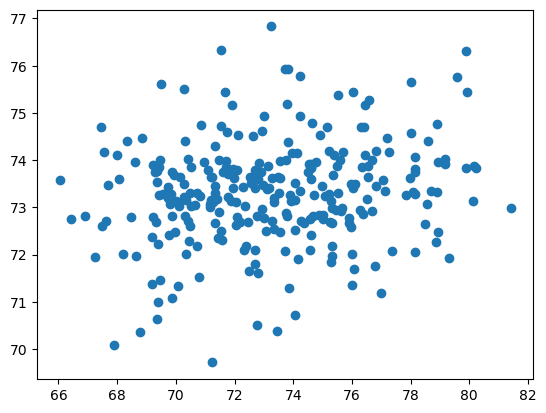

In [47]:
# Полиномиальная регрессия. Полиномы 2-3 степени часто показывают хорошую точность модели
from sklearn.preprocessing import PolynomialFeatures

# Создание полиномиальных признаков
poly = PolynomialFeatures(degree=2)
x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)
from sklearn.linear_model import LinearRegression

# Обучение модели
model_L = LinearRegression()
model_L.fit(x_poly_train, y_train)

y_poly_pred = model_L.predict(x_poly_test)

# Метрики для оценки модели
poly_mse = mean_squared_error(y_test, y_poly_pred)
poly_mae = mean_absolute_error(y_test, y_poly_pred)
poly_R2 = r2_score(y_test, y_poly_pred)

print("Poly Model - Mean Squared Error:", poly_mse)
print("Poly Model - Mean Absolute Error:", poly_mae)
print("Poly Model - R2:", poly_R2)

plt.scatter(y_test, y_poly_pred)


In [48]:
# Модель KNN regressor
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)
KN_regressor = KNeighborsRegressor(n_neighbors=10)
KN_regressor.fit(x_train, y_train)

y_KN_pred = KN_regressor.predict(x_test)

# Метрики для оценки модели
KN_mse = mean_squared_error(y_test, y_KN_pred)
KN_mae = mean_absolute_error(y_test, y_KN_pred)
KN_R2 = r2_score(y_test, y_KN_pred)

print("KN Model - Mean Squared Error:", KN_mse)
print("KN Model - Mean Absolute Error:", KN_mae)
print("KN Model - R2:", KN_R2)

KN Model - Mean Squared Error: 10.312006955918335
KN Model - Mean Absolute Error: 2.667358968221645
KN Model - R2: -0.03882566227322615


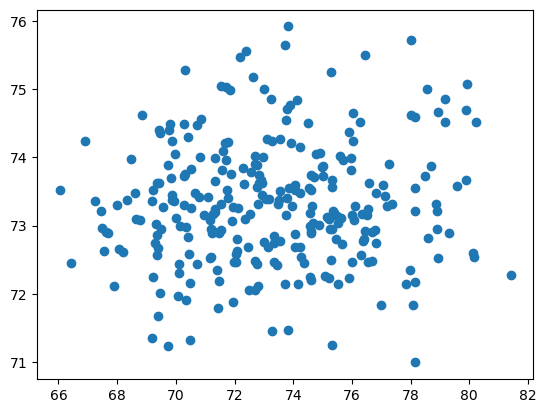

In [49]:
# Модель К-ближайших соседей не показала улучшений по коэффициенту детерминации. 
plt.scatter(y_test, y_KN_pred)

In [73]:
# Целесообразно попытаться сократить количество независимых переменных с учетом  их взаимозависимости, чтобы не перегружать модель
# многомерностью пространства и поддерживать производительность, получать надёжные результаты. Выделение наиболее значимых признаков 
# поможет повысить точность прогнозирования.
# Используем для этих целей библиотеку Eli5 для объяснения моделей машинного обучения, которая помогает объяснять вклад каждой
# переменной в модель.
# Определим ряд пременных по наибольшему влиянию на результат в линейной регрессии.
!pip install eli5
import eli5
from eli5.sklearn import PermutationImportance
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
perm= PermutationImportance (lr_model, random_state=42).fit(x_test, y_test)
eli5.show_weights(perm, feature_names = x_test.columns.tolist())


Weight,Feature
0.0066 ± 0.0110,"Содержание эпоксидных групп,%_2"
0.0026 ± 0.0068,Соотношение матрица-наполнитель
0.0014 ± 0.0005,"Количество отвердителя, м.%"
0.0014 ± 0.0024,Плотность нашивки
0.0007 ± 0.0006,"Угол нашивки, град"
0.0006 ± 0.0056,"Поверхностная плотность, г/м2"
0.0002 ± 0.0009,"Плотность, кг/м3"
0.0000 ± 0.0076,"Потребление смолы, г/м2"
-0.0009 ± 0.0061,"Температура вспышки, С_2"
-0.0013 ± 0.0014,Шаг нашивки


In [56]:
# Проверим, действительно ли метрики улучшатся при ограничении перечня независимых переменных 6 первыми переменными в модели линейной регрессии.
x_reduced = df_norm [['Соотношение матрица-наполнитель', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 
       'Поверхностная плотность, г/м2', 
       'Угол нашивки, град', 'Плотность нашивки']]

y_reduced = df_cleaned['Модуль упругости при растяжении, ГПа']
x_train_reduced, x_test_reduced, y_train_reduced, y_test_reduced = train_test_split(x_reduced, y_reduced,
                                                                   test_size=0.30, random_state=42)

# Посмотрим, как работет модель на сокращенном наборе переменных 
# Модель линейной регрессии
lr_model2 = LinearRegression()
lr_model2.fit(x_train_reduced, y_train_reduced)
y_lr_model_test_pred2 = lr_model2.predict(x_test_reduced)

# Метрики для оценки модели с сокращенным перечнем независимых переменных
lr2_mse = mean_squared_error(y_test_reduced, y_lr_model_test_pred2)
lr2_mae = mean_absolute_error(y_test_reduced, y_lr_model_test_pred2) 
lr2_R2 = r2_score(y_test_reduced, y_lr_model_test_pred2)

print("Liner Model - Mean Squared Error:", lr2_mse)
print("Liner Model - Mean Absolute Error:", lr2_mae)
print("Liner Model - R2:", lr2_R2)

Liner Model - Mean Squared Error: 9.863247149715498
Liner Model - Mean Absolute Error: 2.5822827352077344
Liner Model - R2: 0.006382143042761412


In [ ]:
# Выделение наиболее важных независимых переменных дало видимое улучшение значения коэффиицента детерминации, однако оно осталось низким.
# Используем выделенные переменные при построении следующих моделей.

In [57]:
# Модель градиентного бустинга
x_train_reduced, x_test_reduced, y_train_reduced, y_test_reduced = train_test_split(x_reduced, 
                                            y_reduced, test_size=0.30, random_state=42)
GBR_model = GradientBoostingRegressor(loss='absolute_error',
                                learning_rate=0.1,
                                n_estimators=300,
                                max_depth = 1, 
                                random_state = 42,
                                max_features = 5)

GBR_model.fit(x_train_reduced, y_train_reduced)
GBR_pred = GBR_model.predict(x_test_reduced)

# Метрики для оценки модели
GBR_mse = mean_squared_error(y_test_reduced, GBR_pred)
GBR_mae = mean_absolute_error(y_test_reduced, GBR_pred)
GBR_R2 = r2_score(y_test_reduced, GBR_pred)
print("GBR Model - Mean Squared Error:", GBR_mse)
print("GBR Model - Mean Absolute Error:", GBR_mae)
print("GBR Model - R2:", GBR_R2)

GBR Model - Mean Squared Error: 9.781936561816543
GBR Model - Mean Absolute Error: 2.553385527368249
GBR Model - R2: 0.014573325000360793


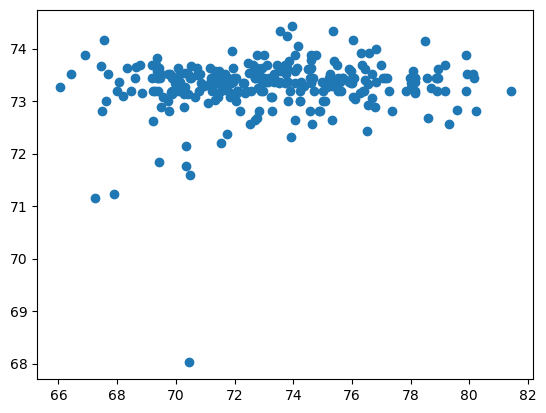

In [58]:
# Модель градиентного бустинга также дает низкую точность и не может использоваться для описания изменений в наблюдаемых значениях "у"
plt.scatter(y_test_reduced, GBR_pred)

In [82]:
# Модели опорных векторов с разными вариантами функции ядра: базисной, линейной и полиномиальной.
svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
svr_lin = SVR(kernel="linear", C=100, gamma="auto")
svr_poly = SVR(kernel="poly", C=100, gamma="auto", degree=4, epsilon=0.1, coef0=1)

svrs_model = [svr_rbf, svr_lin, svr_poly]

for svr in svrs_model:
    svr.fit(x_train_reduced, y_train_reduced)

svr_rbf_pred = svr_rbf.predict(x_test_reduced)
svr_lin_pred = svr_lin.predict(x_test_reduced)
svr_poly_pred = svr_poly.predict(x_test_reduced)

# Метрики для оценки модели
svr_rbf_mse = mean_squared_error(y_test_reduced, svr_rbf_pred)
svr_rbf_mae = mean_absolute_error(y_test_reduced, svr_rbf_pred)
svr_rbf_R2 = r2_score(y_test_reduced, svr_rbf_pred)
svr_lin_mse = mean_squared_error(y_test_reduced, svr_lin_pred)
svr_lin_mae = mean_absolute_error(y_test_reduced, svr_lin_pred)
svr_lin_R2 = r2_score(y_test_reduced, svr_lin_pred)
svr_poly_mse = mean_squared_error(y_test_reduced, svr_poly_pred)
svr_poly_mae = mean_absolute_error(y_test_reduced, svr_poly_pred)
svr_poly_R2 = r2_score(y_test_reduced, svr_poly_pred)

print("SVR1 Model - Mean Squared Error:", svr_rbf_mse)
print("SVR1 Model - Mean Absolute Error:", svr_rbf_mae)
print("SVR1 Model - R2:", svr_rbf_R2)
print("SVR2 Model - Mean Squared Error:", svr_lin_mse)
print("SVR2 Model - Mean Absolute Error:", svr_lin_mae)
print("SVR2 Model - R2:", svr_lin_R2)
print("SVR3 Model - Mean Squared Error:", svr_poly_mse)
print("SVR3 Model - Mean Absolute Error:", svr_poly_mae)
print("SVR3 Model - R2:", svr_poly_R2)

SVR1 Model - Mean Squared Error: 10.084014153289305
SVR1 Model - Mean Absolute Error: 2.606372611105143
SVR1 Model - R2: -0.01585779819040578
SVR2 Model - Mean Squared Error: 9.987859077534305
SVR2 Model - Mean Absolute Error: 2.582566787489964
SVR2 Model - R2: -0.006171191046023372
SVR3 Model - Mean Squared Error: 10.22018294708419
SVR3 Model - Mean Absolute Error: 2.615698889576553
SVR3 Model - R2: -0.02957536432468122


In [ ]:
# Данный класс моделей также не дал значимых результатов.

In [75]:
# Используем Pipeline машинного обучения как конвейер с использованием стандартизации, функции регрессии Ridge и поиском наилучших параметров
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Создание Pipeline со стандартизацией данных и обучением модели Ridge регрессии 
pipe = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge())])

# Задание сетки гиперпараметров для GridSearchCV
param_grid = { 'regressor__alpha': [0.1, 1.0, 10.0, 100],
    'regressor__solver': ['auto', 'svd', 'cholesky']}

# Создание объекта GridSearchCV с использованием Pipeline
grid_search = GridSearchCV(pipe, param_grid=param_grid, cv=5)

# Подбор модели и выполнение поиска по сетке гиперпараметров
grid_search.fit(x_train_reduced, y_train_reduced)

# Получение наилучших гиперпараметров и оценка модели
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Предсказание на тестовом наборе данных с использованием наилучшей модели
y_predP = grid_search.predict(x_test_reduced)

print("Best parameters:", best_params)
print("Best score:", best_score)    

Best parameters: {'regressor__alpha': 100, 'regressor__solver': 'auto'}
Best score: -0.024304617611658808


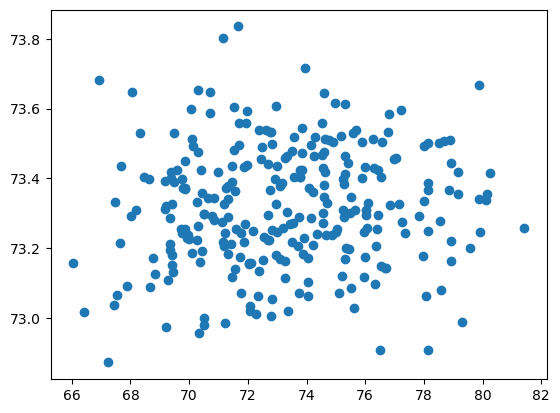

In [76]:
# Использование Pipeline не дало улучшений.
# В целом использованные модели регрессии не обладают требуемой точностью и не могут применяться
# в целях прогнозирования целевого показателя.
plt.scatter(y_test_reduced, y_predP)

In [11]:
# В завершении раздела прогнозирования модуля упругости при растяжении используем простую нейронную сеть
# Еще раз загружаем данные из сохраненного Excel- файла и проверяем правильность данной загрузки
df_cleaned = pd.read_excel(r"C:\Users\User\Desktop\Data Science\Файл очищенные данные.xlsx")
df_cleaned.head(15)

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.000000,3000.000000,220.0,0,4.0,60.0
1,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.000000,3000.000000,220.0,0,5.0,47.0
2,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.000000,3000.000000,220.0,0,5.0,57.0
3,2.767918,2000.0,748.000000,111.86,22.267857,284.615385,210.0,70.000000,3000.000000,220.0,0,5.0,60.0
4,2.569620,1910.0,807.000000,111.86,22.267857,284.615385,210.0,70.000000,3000.000000,220.0,0,5.0,70.0
5,2.561475,1900.0,535.000000,111.86,22.267857,284.615385,380.0,75.000000,1800.000000,120.0,0,7.0,47.0
6,3.557018,1930.0,889.000000,129.00,21.250000,300.000000,380.0,75.000000,1800.000000,120.0,0,7.0,57.0
7,3.532338,2100.0,1421.000000,129.00,21.250000,300.000000,1010.0,78.000000,2000.000000,300.0,0,7.0,60.0
8,2.919678,2160.0,933.000000,129.00,21.250000,300.000000,1010.0,78.000000,2000.000000,300.0,0,7.0,70.0
9,2.877358,1990.0,1628.000000,129.00,21.250000,300.000000,1010.0,78.000000,2000.000000,300.0,0,9.0,47.0


In [40]:
# Используем в качестве переменных выделенные ранее наиболее значимые 6 переменных. Нормализуем данные и создаем
# нейронную сеть на базе последовательной модели Sequential с 4 полносвязными слоями Dense и втроенной нормализацией 
# данных BatchNormalization.

x_N = df_cleaned [['Соотношение матрица-наполнитель', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 
       'Поверхностная плотность, г/м2', 
       'Угол нашивки, град', 'Плотность нашивки']]

y_N = df_cleaned ['Модуль упругости при растяжении, ГПа']
x_trainN, x_testN, y_trainN, y_testN = train_test_split(x_N, y_N, test_size=0.30, random_state=42)

from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras import layers
from keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
model= Sequential()
model.add(Dense(128, activation='relu', input_shape=(x_trainN.shape[1],), kernel_regularizer= l2(0.003)))
model.add(BatchNormalization())
model.add(Dense(256, activation='relu', kernel_regularizer= l2(0.003)))
model.add(BatchNormalization())
model.add(Dense(64, activation='relu', kernel_regularizer= l2(0.003)))
model.add(BatchNormalization())
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.R2Score()])
early_stopping = EarlyStopping(monitor='val_loss', patience=7)

# Обучение модели на условиях : количество эпох 100, партии выборок переменных для обучения - по 15, 
# ранняя остановка при отсутствии улучшений после 7 эпох и выводом метрик после каждой эпохи. 
model.fit(x_trainN, y_trainN, epochs=int(100), batch_size=15, validation_split=0.2, verbose=1, callbacks=[early_stopping])

Epoch 1/100


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5356.4136 - r2_score: -592.2198 - val_loss: 5290.7666 - val_r2_score: -591.2974
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5275.9648 - r2_score: -583.3434 - val_loss: 5102.0732 - val_r2_score: -570.1724
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5152.9956 - r2_score: -569.7232 - val_loss: 5168.4224 - val_r2_score: -577.6021
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4979.1831 - r2_score: -550.5587 - val_loss: 4721.1338 - val_r2_score: -527.5212
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4755.9692 - r2_score: -525.7728 - val_loss: 4458.0078 - val_r2_score: -498.0602
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4487.1729 - r2_score: -495.9694 - val_loss: 4302.8477 - val_r2_score: -480.6875
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4179.5659 - r2_score: -461.8703 - val_loss: 3944.0977 - val_r2_score: -440.5196
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


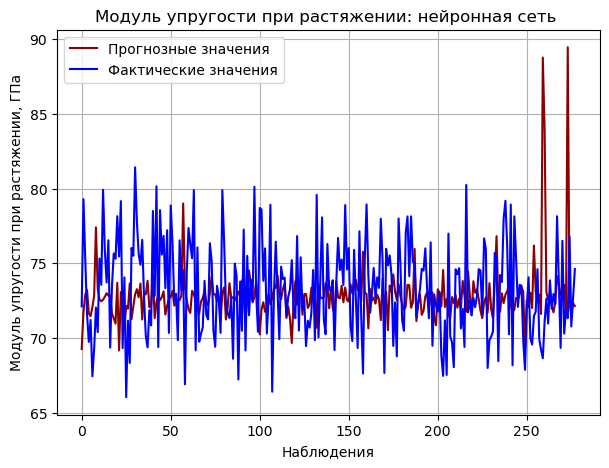

In [41]:
y_predN = model.predict(x_testN)
plt.figure(figsize = (7,5))
plt.title("Модуль упругости при растяжении: нейронная сеть ")
plt.plot(y_predN, label = "Прогнозные значения", color = 'darkred')
plt.plot(y_testN.values, label = "Фактические значения", color = 'blue')
plt.xlabel("Наблюдения")
plt.ylabel("Модуль упругости при растяжении, ГПа")
plt.legend()
plt.grid(True)

# 4.2  МОДЕЛИРОВАНИЕ ЗНАЧЕНИЙ ПРОЧНОСТИ ПРИ РАСТЯЖЕНИИ

In [84]:
# Задание перечня независмых и зависимой переменной модели с ичключением второй целевой переменной значений модуля упругости при растяжении.
x1 = df_norm [['Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Потребление смолы, г/м2',
       'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки']]

y1 = df_cleaned ['Прочность при растяжении, МПа']
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.30, random_state=42)
df_norm.shape[0] - x1_train.shape[0] - x1_test.shape[0]

0

In [85]:
# По аналогии с ранее проведенным анализом начинаем с более простых регрессионных моделей
# Дерево решений
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(x1_train, y1_train)

# Модель "случайного леса"
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_model.fit(x1_train, y1_train)

# Модель линейной регрессии
lr_model = LinearRegression()
lr_model.fit(x1_train, y1_train)

tree_pred = tree_model.predict(x1_test)
forest_pred = forest_model.predict(x1_test)
y_lr_model_pred = lr_model.predict(x1_test)

# Метрики для оценки моделей (среднеквадратическая ошибка, средняя абсолютная ошибка, коэффициент детерминации)
tree_mse = mean_squared_error(y1_test, tree_pred)
tree_mae = mean_absolute_error(y1_test, tree_pred)
tree_R2 = r2_score(y1_test, tree_pred)

forest_mse = mean_squared_error(y1_test, forest_pred)
forest_mae = mean_absolute_error(y1_test, forest_pred)
forest_R2 = r2_score(y1_test, forest_pred)

lr_mse = mean_squared_error(y1_test, y_lr_model_pred)
lr_mae = mean_absolute_error(y1_test, y_lr_model_pred) 
lr_R2 = r2_score(y1_test, y_lr_model_pred)

print("Decision Tree Model - Mean Squared Error:", tree_mse)
print("Decision Tree Model - Mean Absolute Error:", tree_mae)
print("Decision Tree Model - R2:", tree_R2)
print("Random Forest Model - Mean Squared Error:", forest_mse)
print("Random Forest Model - Mean Absolute Error:", forest_mae)
print("Random Forest Model - R2:", forest_R2)
print("Liner Model - Mean Squared Error:", lr_mse)
print("Liner Model - Mean Absolute Error:", lr_mae)
print("Liner Model - R2:", lr_R2)

Decision Tree Model - Mean Squared Error: 416653.40069137514
Decision Tree Model - Mean Absolute Error: 519.1793771645767
Decision Tree Model - R2: -1.011119383875109
Random Forest Model - Mean Squared Error: 213538.22998808543
Random Forest Model - Mean Absolute Error: 374.3500956513094
Random Forest Model - R2: -0.030714912718362575
Liner Model - Mean Squared Error: 205376.2690715314
Liner Model - Mean Absolute Error: 362.1713925324197
Liner Model - R2: 0.008681568343534618


In [64]:
# Полиномиальная регрессия
from sklearn.preprocessing import PolynomialFeatures
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.30, random_state=42)
# Создание полиномиальных признаков
poly = PolynomialFeatures(degree=2)
x_poly_train = poly.fit_transform(x1_train)
x_poly_test = poly.transform(x1_test)

from sklearn.linear_model import LinearRegression

# Обучение модели
model = LinearRegression()
model.fit(x_poly_train, y1_train)

y_poly_pred = model.predict(x_poly_test)

# Метрики для оценки модели
poly_mse = mean_squared_error(y1_test, y_poly_pred)
poly_R2 = r2_score(y1_test, y_poly_pred)

print("Poly Model - Mean Squared Error:", poly_mse)
print("Poly Model - R2:", poly_R2)

Poly Model - Mean Squared Error: 234326.30941800945
Poly Model - R2: -0.13105565018908183


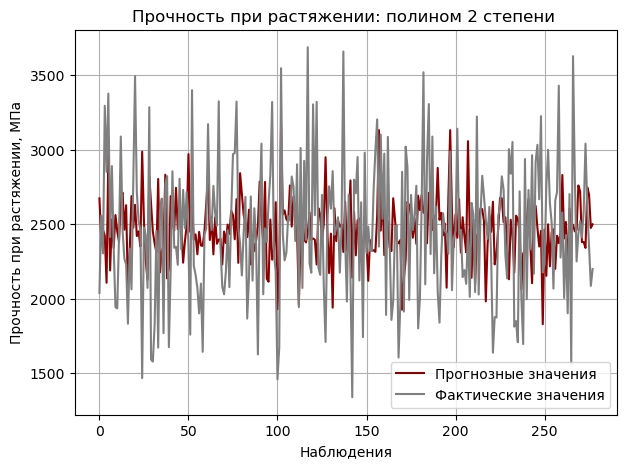

In [66]:
plt.figure(figsize = (7, 5))
plt.title("Прочность при растяжении: полином 2 степени ")
plt.plot(y_poly_pred, label = "Прогнозные значения", color = 'darkred')
plt.plot(y1_test.values, label = "Фактические значения", color = 'grey')
plt.xlabel("Наблюдения")
plt.ylabel("Прочность при растяжении, МПа")
plt.legend()
plt.grid(True)

In [67]:
# Модель KNN regressor
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.30, random_state=42)
KN_regressor = KNeighborsRegressor(n_neighbors=10)
KN_regressor.fit(x1_train, y1_train)

y1_KN_pred = KN_regressor.predict(x1_test)

# Метрики для оценки модели
KN1_mse = mean_squared_error(y1_test, y1_KN_pred)
KN1_mae = mean_absolute_error(y1_test, y1_KN_pred)
KN1_R2 = r2_score(y1_test, y1_KN_pred)

print("KN Model - Mean Squared Error:", KN1_mse)
print("KN Model - Mean Absolute Error:", KN1_mae)
print("KN Model - R2:", KN1_R2)

KN Model - Mean Squared Error: 233371.75431966188
KN Model - Mean Absolute Error: 381.9343168912607
KN Model - R2: -0.12644816526737435


In [68]:
# Выделим наиболее значимые переменные с помощью инструмента PermutationImportance по тому же алгоритму
import eli5
from eli5.sklearn import PermutationImportance
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.30, random_state=42)
lr_model = LinearRegression()
lr_model.fit(x1_train, y1_train)
perm= PermutationImportance (lr_model, random_state=42).fit(x1_test, y1_test)
eli5.show_weights(perm, feature_names = x1_test.columns.tolist())

Weight,Feature
0.0139 ± 0.0099,"Плотность, кг/м3"
0.0081 ± 0.0132,"Количество отвердителя, м.%"
0.0050 ± 0.0100,Шаг нашивки
0.0017 ± 0.0073,"Поверхностная плотность, г/м2"
0.0013 ± 0.0018,"модуль упругости, ГПа"
0.0005 ± 0.0004,"Потребление смолы, г/м2"
0.0003 ± 0.0009,"Температура вспышки, С_2"
-0.0002 ± 0.0055,"Угол нашивки, град"
-0.0006 ± 0.0027,"Содержание эпоксидных групп,%_2"
-0.0020 ± 0.0025,Соотношение матрица-наполнитель


In [70]:
# Используем первые 6 переменных-характеристик для построения моделей машинного обучения.
# Модель линейной регрессии
x1_reduced = df_norm [['Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%', 'Потребление смолы, г/м2', 
       'Поверхностная плотность, г/м2', 'Шаг нашивки']]

y1_reduced = df_cleaned ['Прочность при растяжении, МПа']
x1_train_reduced, x1_test_reduced, y1_train_reduced, y1_test_reduced = train_test_split(x1_reduced, y1_reduced, 
                                                test_size=0.30, random_state=42)

# Посмотрим, как работет модель на сокращенном наборе переменных 
# Модель линейной регрессии
lr1_model = LinearRegression()
lr1_model.fit(x1_train_reduced, y1_train_reduced)
y1_lr_model_pred = lr1_model.predict(x1_test_reduced)

# Метрики для оценки модели с сокращенным перечнем независимых переменных
lr1_mse = mean_squared_error(y1_test_reduced, y1_lr_model_pred)
lr1_mae = mean_absolute_error(y1_test_reduced, y1_lr_model_pred) 
lr1_R2 = r2_score(y1_test_reduced, y1_lr_model_pred)

print("Linear Model opt - Mean Squared Error:", lr1_mse)
print("Linear Model opt - Mean Absolute Error:", lr1_mae)
print("Linear Model opt- R2:", lr1_R2)

Linear Model opt - Mean Squared Error: 202612.32548925333
Linear Model opt - Mean Absolute Error: 359.50846231881144
Linear Model opt- R2: 0.02202268233668314


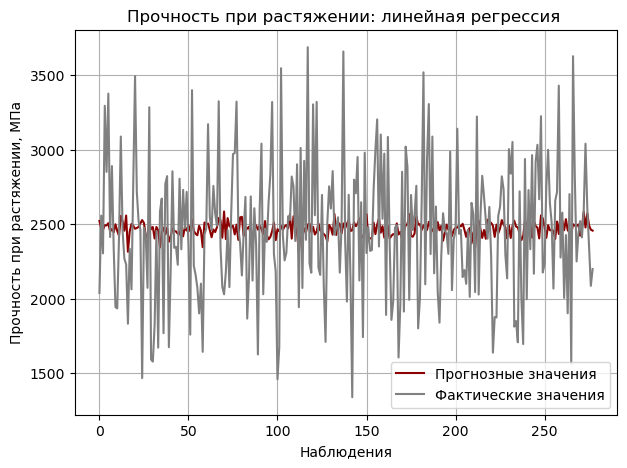

In [71]:
plt.figure(figsize = (7, 5))
plt.title("Прочность при растяжении: линейная регрессия ")
plt.plot(y1_lr_model_pred, label = "Прогнозные значения", color = 'darkred')
plt.plot(y1_test_reduced.values, label = "Фактические значения", color = 'grey')
plt.xlabel("Наблюдения")
plt.ylabel("Прочность при растяжении, МПа")
plt.legend()
plt.grid(True)

In [72]:
# Получим значения коэффициентов и свободного члена уравнения линейной регрессии, как модели с наилучшим результатом для 
# нормализованных значений переменных:
print(f"Коэффициент(ы): {lr1_model.coef_}"), print(f"Свободный член: {lr1_model.intercept_}")

Коэффициент(ы): [-130.10206019   31.02875507 -120.68275784    3.28145551  -80.08873963
 -171.39793845]
Свободный член: 2698.409565860155


(None, None)

In [77]:
# Полиномиальная модель 2 степени
x1_train_reduced, x1_test_reduced, y1_train_reduced, y1_test_reduced = train_test_split(x1_reduced, y1_reduced, 
                                                                              test_size=0.30, random_state=42)
# Создание полиномиальных признаков
poly = PolynomialFeatures(degree=2)
x1_poly_train = poly.fit_transform(x1_train_reduced)
x1_poly_test = poly.transform(x1_test_reduced)

from sklearn.linear_model import LinearRegression

# Обучение модели
model = LinearRegression()
model.fit(x1_poly_train, y1_train_reduced)

y1_poly_pred = model.predict(x1_poly_test)

# Метрики для оценки модели
poly1_mse = mean_squared_error(y1_test_reduced, y1_poly_pred)
poly1_mae = mean_absolute_error(y1_test_reduced, y1_poly_pred)
poly1_R2 = r2_score(y1_test_reduced, y1_poly_pred)

print("Poly Model - Mean Squared Error:", poly1_mse)
print("Poly Model - Mean Absolute Error:", poly1_mae)
print("Poly Model - R2:", poly1_R2)

Poly Model - Mean Squared Error: 203322.83413639246
Poly Model - Mean Absolute Error: 366.61236428458744
Poly Model - R2: 0.0185931706363075


In [78]:
# Модели опорных векторов с вариантами функции ядра: базисной, линейной и полиномиальной.
svr1_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
svr1_lin = SVR(kernel="linear", C=100, gamma="auto")
svr1_poly = SVR(kernel="poly", C=100, gamma="auto", degree=4, epsilon=0.1, coef0=1)

svrs1_model = [svr1_rbf, svr1_lin, svr1_poly]

for svr1 in svrs1_model:
    svr1.fit(x1_train_reduced, y1_train_reduced)

svr1_rbf_pred = svr1_rbf.predict(x1_test_reduced)
svr1_lin_pred = svr1_lin.predict(x1_test_reduced)
svr1_poly_pred = svr1_poly.predict(x1_test_reduced)

# Метрики для оценки модели
svr1_rbf_mse = mean_squared_error(y1_test_reduced, svr1_rbf_pred)
svr1_rbf_mae = mean_absolute_error(y1_test_reduced, svr1_rbf_pred)
svr1_rbf_R2 = r2_score(y1_test_reduced, svr1_rbf_pred)
svr1_lin_mse = mean_squared_error(y1_test_reduced, svr1_lin_pred)
svr1_lin_mae = mean_absolute_error(y1_test_reduced, svr1_lin_pred)
svr1_lin_R2 = r2_score(y1_test_reduced, svr1_lin_pred)
svr1_poly_mse = mean_squared_error(y1_test_reduced, svr1_poly_pred)
svr1_poly_mae = mean_absolute_error(y1_test_reduced, svr1_poly_pred)
svr1_poly_R2 = r2_score(y1_test_reduced, svr1_poly_pred)

print("SVR1 Model - Mean Squared Error:", svr1_rbf_mse)
print("SVR1 Model - Mean Absolute Error:", svr1_rbf_mae)
print("SVR1 Model - R2:", svr1_rbf_R2)
print("SVR2 Model - Mean Squared Error:", svr1_lin_mse)
print("SVR2 Model - Mean Absolute Error:", svr1_lin_mae)
print("SVR2 Model - R2:", svr1_lin_R2)
print("SVR3 Model - Mean Squared Error:", svr1_poly_mse)
print("SVR3 Model - Mean Absolute Error:", svr1_poly_mae)
print("SVR3 Model - R2:", svr1_poly_R2)

SVR1 Model - Mean Squared Error: 203692.96851064888
SVR1 Model - Mean Absolute Error: 358.80301669427786
SVR1 Model - R2: 0.016806591159288065
SVR2 Model - Mean Squared Error: 202164.75595581977
SVR2 Model - Mean Absolute Error: 360.5323534018353
SVR2 Model - R2: 0.02418302895290314
SVR3 Model - Mean Squared Error: 201520.03591824527
SVR3 Model - Mean Absolute Error: 361.0325897727709
SVR3 Model - R2: 0.027294989547937853


In [79]:
# Использование Pipeline машинного обучения и Модели градиентного бустинга не дают в случае прогнозирования 
# модуля прочности при растяжении значимых результатов.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
x1_train_reduced, x1_test_reduced, y1_train_reduced, y1_test_reduced = train_test_split(x1_reduced, y1_reduced, test_size=0.30, random_state=42)

# Создание Pipeline со стандартизацией данных и обучением модели Ridge регрессии
pipe = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge())])

# Задание сетки гиперпараметров для GridSearchCV
param_grid = { 'regressor__alpha': [0.1, 1.0, 10.0, 100],
    'regressor__solver': ['auto', 'svd', 'cholesky']}

# Создание объекта GridSearchCV с использованием Pipeline
grid_search = GridSearchCV(pipe, param_grid=param_grid, cv=5)

# Подбор модели и выполнение поиска по сетке гиперпараметров
grid_search.fit(x1_train_reduced, y1_train_reduced)

# Получение наилучших гиперпараметров и оценка модели
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Предсказание на тестовом наборе данных с использованием наилучшей модели
y1_pred = grid_search.predict(x1_test_reduced)

print("Best parameters:", best_params)
print("Best score:", best_score)   

Best parameters: {'regressor__alpha': 100, 'regressor__solver': 'svd'}
Best score: -0.015653901689333626


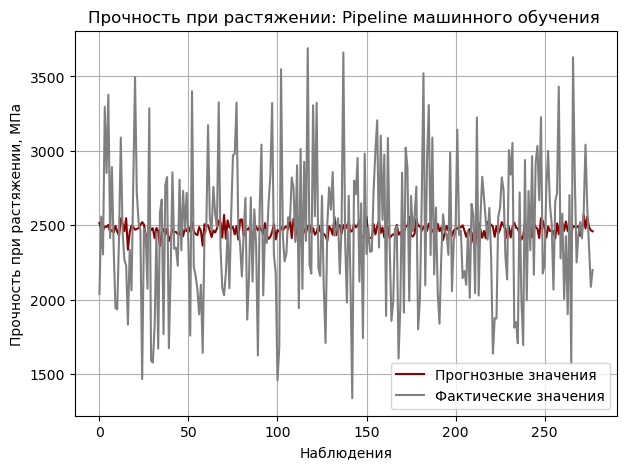

In [80]:
plt.figure(figsize = (7, 5))
plt.title("Прочность при растяжении: Pipeline машинного обучения ")
plt.plot(y1_pred, label = "Прогнозные значения", color = 'darkred')
plt.plot(y1_test_reduced.values, label = "Фактические значения", color = 'grey')
plt.xlabel("Наблюдения")
plt.ylabel("Прочность при растяжении, МПа")
plt.legend()
plt.grid(True)

In [81]:
# Модель градиентного бустинга
x1_train_reduced, x1_test_reduced, y1_train_reduced, y1_test_reduced = train_test_split(x1_reduced, y1_reduced, 
                                                                            test_size=0.30, random_state=42)
GBR1_model = GradientBoostingRegressor(loss='absolute_error',
                                learning_rate=0.1,
                                n_estimators=300,
                                max_depth = 1, 
                                random_state = 42,
                                max_features = 5)

GBR1_model.fit(x1_train_reduced, y1_train_reduced)
GBR1_pred = GBR1_model.predict(x1_test_reduced)

# Метрики для оценки модели
GBR1_mse = mean_squared_error(y1_test_reduced, GBR1_pred)
GBR1_mae = mean_absolute_error(y1_test_reduced, GBR1_pred)
GBR1_R2 = r2_score(y1_test_reduced, GBR1_pred)
print("GBR1 Model - Mean Squared Error:", GBR1_mse)
print("GBR1 Model - Mean Absolute Error:", GBR1_mae)
print("GBR1 Model - R2:", GBR1_R2)

GBR1 Model - Mean Squared Error: 208489.63082927663
GBR1 Model - Mean Absolute Error: 367.4982888848489
GBR1 Model - R2: -0.006346131345528638


In [ ]:
# Как и в случае с прогнозированием модуля упругости, при множественном переборе групп независимых переменных не удалось получить хорошую
# с предсказательной точки зрения модель регрессии.

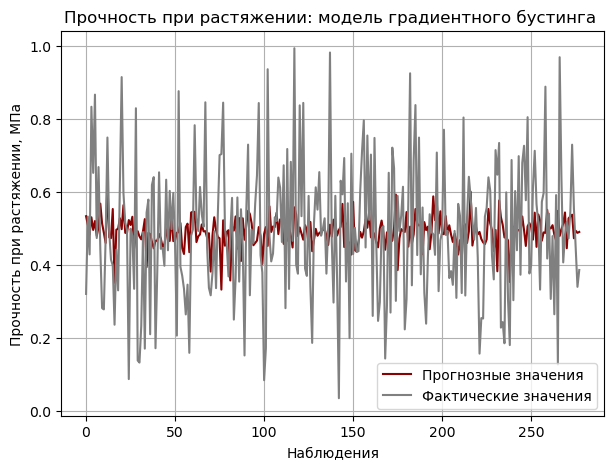

In [205]:
plt.figure(figsize = (7, 5))
plt.title("Прочность при растяжении: модель градиентного бустинга ")
plt.plot(GBR1_pred, label = "Прогнозные значения", color = 'darkred')
plt.plot(y1_test_reduced.values, label = "Фактические значения", color = 'grey')
plt.xlabel("Наблюдения")
plt.ylabel("Прочность при растяжении, МПа")
plt.legend()
plt.grid(True)

In [33]:
# Для построения нейронной сети с целью прогнозирования ПРОЧНОСТИ ПРИ РАСТЯЖЕНИИ используем в качестве переменных выделенные ранее наиболее
# значимые 6 переменных. Используем пакетную нормализацию.
# Нейронная сеть создана на базе последовательной модели Sequential с 5 полносвязными слоями Dense.

x_N1 = df_cleaned [['Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%', 'Потребление смолы, г/м2', 
       'Поверхностная плотность, г/м2', 'Шаг нашивки']]

y_N1 = df_cleaned ['Прочность при растяжении, МПа']
x_trainN1, x_testN1, y_trainN1, y_testN1 = train_test_split(x_N1, y_N1, test_size=0.30, random_state=42)

from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras import layers
from keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
model= Sequential()
model.add(Dense(128, activation='relu', input_shape=(x_trainN1.shape[1],), kernel_regularizer= l2(0.003)))
model.add(BatchNormalization())
model.add(Dense(256, activation='relu', kernel_regularizer= l2(0.003)))
model.add(BatchNormalization())
model.add(Dense(64, activation='relu', kernel_regularizer= l2(0.003)))
model.add(BatchNormalization())
model.add(Dense(64, activation='relu', kernel_regularizer= l2(0.003)))
model.add(Dense(1, activation='relu'))

model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.R2Score()])
early_stopping = EarlyStopping(monitor='val_loss', patience=7)

# Обучение модели на условиях : количестиво эпох 200, партии выборок переменных для обучения - по 15, ранняя остановка при отсутствии 
# улучшений после 7 эпох и выводом метрик после каждой эпохи. 
model.fit(x_trainN1, y_trainN1, epochs=int(200), batch_size=15, validation_split=0.2, verbose=1, callbacks=[early_stopping])

Epoch 1/200


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 6341616.0000 - r2_score: -29.3401 - val_loss: 6128864.0000 - val_r2_score: -24.5523
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6287051.5000 - r2_score: -29.0791 - val_loss: 6146337.0000 - val_r2_score: -24.6252
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6167444.5000 - r2_score: -28.5070 - val_loss: 6048612.5000 - val_r2_score: -24.2178
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5971695.5000 - r2_score: -27.5705 - val_loss: 5862105.5000 - val_r2_score: -23.4402
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5681264.5000 - r2_score: -26.1809 - val_loss: 5471921.0000 - val_r2_score: -21.8134
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5294331.0000 - r2_score: -24.3295 - val_loss: 4926271.0000 - val_r2_score: -19.5385
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4798250.5000 - r2_score: -21.9564 - val_loss: 3844453.0000 - val_r2_score: -15.0282
Epoch 8/20

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


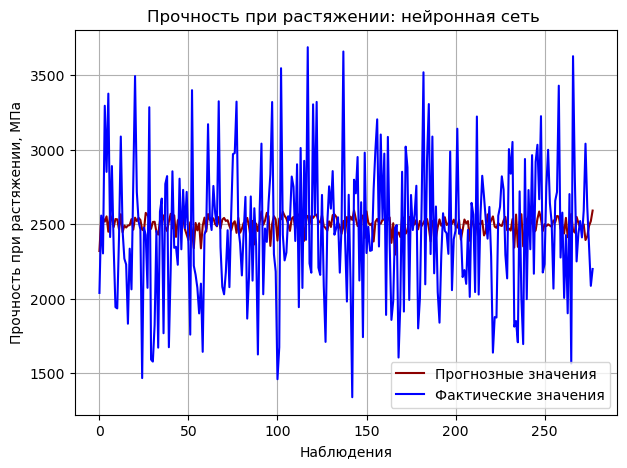

In [11]:
# Созданная нейронная сеть не обладает прогнозной ценностью с учетом значений коэффициента детерминации и потерь.
y_predN1 = model.predict(x_testN1)

plt.figure(figsize =(7,5))
plt.title("Прочность при растяжении: нейронная сеть ")
plt.plot(y_predN1, label = "Прогнозные значения", color = 'darkred')
plt.plot(y_testN1.values, label = "Фактические значения", color = 'blue')
plt.xlabel("Наблюдения")
plt.ylabel("Прочность при растяжении, МПа")
plt.legend()
plt.grid(True)

# 5. СОЗДАНИЕ НЕЙРОННОЙ СЕТИ ДЛЯ РЕКОМЕНДАЦИИ СООТНОШЕНИЯ "МАТРИЦА-НАПОЛНИТЕЛЬ"

In [12]:
df_cleaned. head(10)

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
1,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
2,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0
3,2.767918,2000.0,748.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,60.0
4,2.569620,1910.0,807.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,70.0
5,2.561475,1900.0,535.000000,111.86,22.267857,284.615385,380.0,75.0,1800.0,120.0,0,7.0,47.0
6,3.557018,1930.0,889.000000,129.00,21.250000,300.000000,380.0,75.0,1800.0,120.0,0,7.0,57.0
7,3.532338,2100.0,1421.000000,129.00,21.250000,300.000000,1010.0,78.0,2000.0,300.0,0,7.0,60.0
8,2.919678,2160.0,933.000000,129.00,21.250000,300.000000,1010.0,78.0,2000.0,300.0,0,7.0,70.0
9,2.877358,1990.0,1628.000000,129.00,21.250000,300.000000,1010.0,78.0,2000.0,300.0,0,9.0,47.0


In [18]:
# В качестве зависимой целевой переменной выступает соотношение матрица-наполнитель. Для получения рекомендации вводятся значения
# следующих выбранных нами 8 независимых переменных-показателей:
xS = df_cleaned [['Прочность при растяжении, МПа', 'Модуль упругости при растяжении, ГПа', 'Количество отвердителя, м.%', 
                  'Плотность, кг/м3',   'Поверхностная плотность, г/м2', 'Содержание эпоксидных групп,%_2', 
                  'Угол нашивки, град', 'Плотность нашивки']]

yS = df_cleaned ['Соотношение матрица-наполнитель']

x_trainS, x_testS, y_trainS, y_testS = train_test_split(xS, yS, test_size=0.30, random_state=42)

from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras import layers
from keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
# В архитектуре нейронной сети используются простые слои Dense и встроенный пакетный нормализатор BatchNormalization:
modelS= Sequential()
modelS.add(Dense(128, activation='relu', input_shape=(x_trainS.shape[1],), kernel_regularizer= l2(0.003)))
modelS.add(BatchNormalization())
modelS.add(Dense(256, activation='relu', kernel_regularizer= l2(0.003)))
modelS.add(BatchNormalization())
modelS.add(Dense(64, activation='relu', kernel_regularizer= l2(0.003)))
modelS.add(BatchNormalization())
modelS.add(Dense(1, activation='relu'))

modelS.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.R2Score()])
early_stopping = EarlyStopping(monitor='val_loss', patience=7)
# Вывод параметров модели
modelS.summary()
# Обучение модели на условиях: количество эпох 200, партии выборок переменных для обучения - по 12, ранняя остановка при отсутствии улучшений 
# после 7 эпох и выводом метрик после каждой эпохи. 
modelS.fit(x_trainS, y_trainS, epochs=int(200), batch_size=12, validation_split=0.2, verbose=1, callbacks=[early_stopping])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,481 (205.00 KB)

 Trainable params: 51,585 (201.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5.8702 - r2_score: -5.6387 - val_loss: 11.1156 - val_r2_score: -12.0655
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6660 - r2_score: -4.1733 - val_loss: 11.0676 - val_r2_score: -12.0655
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0094 - r2_score: -3.3562 - val_loss: 11.0488 - val_r2_score: -12.0655
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5235 - r2_score: -2.7408 - val_loss: 9.0718 - val_r2_score: -9.5919
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.4053 - r2_score: -2.5985 - val_loss: 6.9794 - val_r2_score: -6.9683
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.0465 - r2_score: -2.1369 - val_loss: 7.7186 - val_r2_score: -7.9039
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8687 - r2_score: -1.9071 - val_loss: 2.6883 - val_r2_score: -1.5730
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3664 - r2_score: -1.2527 - val

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


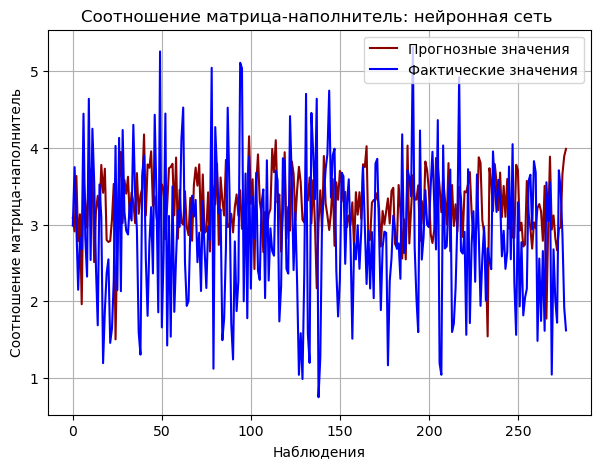

In [19]:
# Визуализируем фактические (тестовый набор) и прогнозные значения целевой переменной- соотношения матрица-наполнитель
y_predS = modelS.predict(x_testS)
plt.figure(figsize =(7,5))
plt.title("Соотношение матрица-наполнитель: нейронная сеть ")
plt.plot(y_predS, label = "Прогнозные значения", color = 'darkred')
plt.plot(y_testS.values, label = "Фактические значения", color = 'blue')
plt.xlabel("Наблюдения")
plt.ylabel("Соотношение матрица-наполнитель")
plt.legend()
plt.grid(True)

In [21]:
# Сохраним полученную нейронную сеть (modelS) для соотношения матрица-наполнитель в формате keras
modelS.save('model.keras')
# Загрузим сохраненную нейронную сеть с диска
modelS_loaded = keras.models.load_model('model.keras')

In [52]:
# Метрики потерь при работе модели
modelS_loaded.evaluate(x_testS, y_testS)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8856 - r2_score: -0.0073     


[0.8855821490287781, -0.007261753082275391]

In [23]:
ySpred = modelS.predict(xS)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [24]:
# Посмотрим на прогнозные соотношения матрица-0наполнитель при работе модели на фактических очищенных от выбросов данных датасета
ySpred

array([[3.1926022 ],
       [2.9742336 ],
       [3.02551   ],
       [2.9607692 ],
       [2.7687848 ],
       [3.4399943 ],
       [3.5379715 ],
       [3.7892914 ],
       [3.858076  ],
       [3.6312706 ],
       [3.512837  ],
       [3.5789702 ],
       [3.3526566 ],
       [2.9742336 ],
       [2.6576912 ],
       [3.5624564 ],
       [3.5057654 ],
       [3.7477422 ],
       [3.2143402 ],
       [3.1525972 ],
       [2.879119  ],
       [2.5883284 ],
       [2.8325474 ],
       [2.9462314 ],
       [3.2036366 ],
       [3.3251424 ],
       [3.0548825 ],
       [3.3340957 ],
       [3.17866   ],
       [2.9327242 ],
       [3.6350806 ],
       [3.0749545 ],
       [3.1529284 ],
       [3.4232697 ],
       [3.4620948 ],
       [3.1581697 ],
       [3.27508   ],
       [3.1228333 ],
       [3.0147443 ],
       [3.4157257 ],
       [3.8681307 ],
       [3.394023  ],
       [2.7440104 ],
       [2.807726  ],
       [2.9184337 ],
       [3.5702887 ],
       [3.7285903 ],
       [3.435